In [1]:
print('Hello World')

Hello World


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")

In [4]:
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY is not set in the environment variables.")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

chat_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [6]:
chat_llm.invoke("Hello,How are you?").content

"Hello! I'm doing well, thank you for asking.\n\nHow are you today?"

In [7]:
from typing_extensions import TypedDict,Annotated
import operator
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage

In [8]:
class GraphState(TypedDict):
    messages:Annotated[list[AnyMessage],operator.add]

In [9]:
{
    "messages": [HumanMessage(content="Hi, this is varshitha. Say hello in detail.")]
}


{'messages': [HumanMessage(content='Hi, this is varshitha. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [10]:
["hi"]

['hi']

In [11]:
["hi","how are you?"]

['hi', 'how are you?']

In [12]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [13]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [14]:
from langgraph.graph import StateGraph

In [15]:
builder = StateGraph(GraphState)

In [16]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [17]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [18]:
app = builder.compile()

In [19]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [20]:
from IPython.display import Image, display

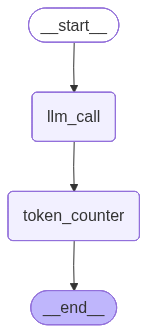

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is varshitha. Say hello in detail.")]
})

In [23]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is varshitha. Say hello in detail.
AIMessage : Well hello there, Varshitha!

It's absolutely wonderful to connect with you. I'm here and ready to assist you in any way I can. Please feel free to share whatever you have in mind or whatever you'd like to discuss.

Looking forward to our interaction!
AIMessage : Total token number in the generated answer (word count) is 44


In [24]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x7ba12dfd0170>, default_metadata=(), model_kwargs={})

In [25]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

/tmp/ipykernel_26061/2961514931.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun


In [26]:

api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [27]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [28]:
wiki_tool.run({"query":"Generative AI"})

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [29]:
import requests

url = "https://en.wikipedia.org/w/api.php"

params = {
    "action": "query",
    "format": "json",
    "list": "search",
    "srsearch": "Generative AI"
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)
print("Headers:", response.headers.get("content-type"))
print("Response Text:")
print(response.text[:1000])

Status Code: 403
Headers: text/plain
Response Text:
Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.



In [30]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [31]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/tmp/ipykernel_26061/1068719361.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [32]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': "### Ideas for Preparing More Career-Ready Graduates\n\nImage 3: Jay Akridge's avatarImage 4: David Hummels's avatar\n\nJay Akridge and David Hummels\n\nDec 19, 2025\n\n14\n\n12\n\nShare\n\nWe’ve written a couple of times this fall on the current job market for new college graduates. The bottom-line: the Class of 2026 is likely to have more trouble finding a job.\n\nStudents are concerned: about 61% of the Class of 2026 students find current news about the job market somewhat or very pessimistic – up from 50% for the Class of 2024. High competition for jobs and lack of available jobs top the list of reasons for that pessimism, with the political climate and AI much more important factors this year relative to last.\n\nImage 5\n\nSource: Handshake. [...] #### Some Final Thoughts\n\nA sof

In [33]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [34]:
search.invoke("what is the latest update on iphone17 release?")

'Oct 9, 2025 · Apple has unveiled four new iPhones: the iPhone 17, iPhone Air, iPhone 17 Pro and iPhone 17 Pro Max. Here’s the lowdown on the specs, price, new features, design, dimensions and more. 4 days ago · Apple describes the update as a bug fix rather than a feature release, and it is rolling out now to support iPhone Air and iPhone 17 models, according to 9to5 Mac. Sep 9, 2025 · Topline Apple unveiled new iPhone models at its annual release event Tuesday, revealing improvements for its flagship product alongside the launch of new AirPods and Apple Watch models. Sep 19, 2025 · Whether you pre-ordered your new iPhone last week or you’re grabbing it from a local Apple Store, it will be an exciting day when your shiny new iPhone 17, iPhone Air, or iPhone 17 Pro model ... 5 days ago · The iPhone 17 was released in September 2025, which means now is a good time to buy. A new model is not expected until early 2027, because Apple is changing its entry-level iPhone timing....'

In [35]:
from langchain_community.tools import YouTubeSearchTool

In [36]:
tool=YouTubeSearchTool()


In [37]:
tool.name

'youtube_search'

In [38]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [39]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=d2kxUVwWWwU&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [40]:
tool.run("sunny savita")

"['https://www.youtube.com/watch?v=ENzZuvahKwc&pp=ygUMc3Vubnkgc2F2aXRh', 'https://www.youtube.com/watch?v=Tf2ZzrCBJUI&pp=ygUMc3Vubnkgc2F2aXRh']"

In [41]:
def multiply(a:int,b:int) -> int:
    return a*b

In [42]:
multiply(10,20)

200

In [43]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [44]:
from langchain.tools import tool

In [45]:
@tool
def multiply(a:int,b:int) -> int:
    '''This tool is for multiplication'''
    return a*b

In [46]:
multiply.invoke({"a":10,"b":20})

200

In [47]:
multiply.name

'multiply'

In [48]:
multiply.description

'This tool is for multiplication'

In [49]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [50]:
@tool
def get_word_length(word:str) -> int:
    '''this is a tool to counter the length of the word'''
    return(len(word))

In [51]:
get_word_length.invoke("hello world")

11

In [52]:
get_word_length.invoke({"word": "hello world"})

11

In [53]:
@tool
def call_gmail_api(args):
    '''this is a tool to call gmail api'''
    pass

In [54]:
import yfinance as yf

In [55]:
@tool
def get_stock_price(ticker:str) -> str:
    ''' this is a tool to get stock price using yfinance'''
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [56]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2198.90.'

In [57]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $307.34.'

In [58]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $391.00.'

In [59]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹747.05.'

In [60]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x7ba10f4c62a0>),
 StructuredTool(name='get_word_length', description='this is a tool to counter the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x7ba10f42c360>),
 StructuredTool(name='multiply', description='This tool is for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7ba10f42c4a0>)]

In [61]:
tools=[get_stock_price,get_word_length,multiply]

In [62]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x7ba12dfd0170>, default_metadata=(), model_kwargs={})

In [63]:
llm_with_tools=chat_llm.bind_tools(tools)

In [64]:
result=llm_with_tools.invoke("What is the stock price of TCS.NS")

In [65]:
result

AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"ticker": "TCS.NS"}'}, '__gemini_function_call_thought_signatures__': {'787897a0-0e8c-482f-b089-db0c17af863f': 'CuwBAQw51sc+ygYrqvMRsi4W54p7U+cy0jHB+4lv6ldCd/89t24XjTYS3nb0J+A3w4bayglrX/Ui04AwQ+oHNWV58UWTglqEW+o9cnGmKSK8FowtdvTHU1i7jEi0WMBVS+40qVBMn1nLP2mpD/4nysEpEbHb8nEU0hBlY6DUWr6bTn4qveXQAanEHe4xiszh9c2oj/wVznliVreKx8KFozmblHFUBRdSdNd6QRSqq0hZIq4WpZLegmdBytODxpKnX0R65YamjA61HCDn00jVaUId5+qZhBi+Vsh8LWn95lnhKCLQpmMtlXEN0HwKMLM='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9fe2-099a-7363-8b14-6e1cb76d3c48-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': '787897a0-0e8c-482f-b089-db0c17af863f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 146, 'output_tokens': 78, 'total_tokens': 224, 'input_token_details': {'cache_re

In [66]:
result.content

''

In [67]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': '787897a0-0e8c-482f-b089-db0c17af863f',
  'type': 'tool_call'}]

In [68]:
result = llm_with_tools.invoke("the length of the word 'hello world, this is a test sentence?'")

In [69]:
result.content

''

In [70]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hello world, this is a test sentence?'},
  'id': 'c51bc9ab-3402-47d9-8cf2-660fdb4c4bc3',
  'type': 'tool_call'}]

In [71]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")

In [72]:
result.content

''

In [73]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': '03527b4d-cf21-4cc1-9937-397a1194fc69',
  'type': 'tool_call'}]

In [74]:
result=llm_with_tools.invoke("Hi, LLM how are you?")

In [75]:
result.content

"I'm doing great! How can I help you today?"

In [76]:
result.tool_calls

[]

In [77]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [78]:
result.content

[{'type': 'text',
  'text': 'I am sorry, I cannot answer this question. My knowledge cutoff is a while ago and I cannot provide you with any information about the latest Indian union budget report of 2026.',
  'extras': {'signature': 'CrEDAQw51set6DC5XfyNsDOlX7EKYM6dPEprZVZPv6HhwFA+FyOiEY/2Sgvo49YmTgUa+w1odWcr7uVcSl7O5M/Oiw/fD3TXdpP1aDodTCZCmCC5Qvb8gODHZN8xsy2SyUyLmBXOVaqWY1jlU4rGrGctl6mZj6RLyK0gZ3hVJcVWhKS61pvKsTBeJCREPNp5Bm7rRhty7iW/uaybPAcXQJS4Df8JCyC683mGayfKnQpJxSWpvy1OKF3vq18fbR9FmdyIsW5yHBYRYHCqCbjq0LjBDqjhOmeGrsvmUbbRg6P/xrMH3CEv7ovRgflkYqLkGlSw63GDxTZrX5QmY/PiNmDCmO28j1G0w7NFlBuwKqVv7t07X130BhvZTYZLaAdaui10DDukTEkJrsRWrautDqnJk9NomMaJ9+JeHO7UR7dbiODnnivepCOwXW17tmX5HTnYLGy+3Bnuj3OVfFVsB3MPa2nQJNFMw4yM0+vvVGghV0xK4Fb0ZTAwRFr5vDMk6H0JcmQ0DepBMrUU8ODCWcC9VJ9UpN9lWENxPxrvaa9kYi2oq3Z+gjTT1WVL92RUQCj78Q=='}}]

In [79]:
result.tool_calls

[]

In [80]:
[get_stock_price,get_word_length,multiply,wiki_tool]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x7ba10f4c62a0>),
 StructuredTool(name='get_word_length', description='this is a tool to counter the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x7ba10f42c360>),
 StructuredTool(name='multiply', description='This tool is for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7ba10f42c4a0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/varshitha/Desktop/Travel Agent/env/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [81]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [82]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x7ba12dfd0170>, default_metadata=(), model_kwargs={})

In [83]:
llm_with_tools=chat_llm.bind_tools(tools)

In [84]:
chat_llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x7ba12dfd0170>, default_metadata=(), model_kwargs={})

In [85]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [86]:
result.content

''

In [87]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': '5de50a32-7f32-49cf-93f6-defcc9acc905',
  'type': 'tool_call'}]

In [88]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [89]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [90]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [91]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x7ba10f4c62a0>),
 StructuredTool(name='get_word_length', description='this is a tool to counter the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x7ba10f42c360>),
 StructuredTool(name='multiply', description='This tool is for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7ba10f42c4a0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/varshitha/Desktop/Travel Agent/env/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [92]:
function_2 = ToolNode(tools)

In [93]:
workflow = StateGraph(MessagesState)

In [94]:
workflow.add_node("llm", function_1)

In [95]:
workflow.add_node("tools", function_2)

In [96]:
workflow.add_edge(START, "llm")

In [97]:
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)

In [98]:
workflow.add_edge("tools", "llm")

In [99]:
app = workflow.compile()

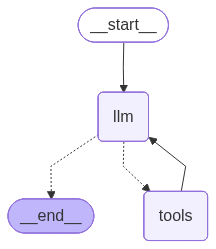

In [100]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [101]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [102]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (cef5760f-2207-43d8-b6d8-0b96442758db)
 Call ID: cef5760f-2207-43d8-b6d8-0b96442758db
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2198.90.
================================== Ai Message ==================================

The last closing price of TCS.NS was ₹2198.90.


In [104]:
result = app.invoke({
    "messages": [HumanMessage(content="how did trump's tariff policy impact the TCS.NS?")]
})

In [105]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================

[{'type': 'text', 'text': "I cannot directly answer how Trump's tariff policy impacted TCS.NS using my tools. Trump's tariff policies primarily targeted goods, while TCS.NS (Tata Consultancy Services) is an IT services company. The impact, if any, would likely be indirect through broader economic shifts, which is beyond the scope of a direct lookup.", 'extras': {'signature': 'CqMZAQw51sev+pQgwbhPI55zBnfO7Y2Dzd3giFvuWMlx3GJTRWLa0I2nq9gIYC+IVKauieQaVW93+yrpJ4ZNnZyQjkgUKo1MXW0TsdbMh+g+I2l721e3LhrDTWUokHYgQjUBBdBA+6HIvxC0RaKsSsk2S+Mlwh1k4dSUnfhyIBRClaht0JCdJ/hJ0zM8EzvVW8eJqESe2jPsmpdIvDEmUEHZauRVz3xJ7sZHJqcQXYKinS1VzIt8YFXE7T6LaLkEfSAt4PtIIt4m/KjpTrYrk0Tqmp0TTwxYoV/eWHU5LSex2GsecWHuK/IYSrAd6vMNNFEanl5HIElTJQAJsH+dYFndLs2gqx6cLChL5sdr5yrZYSEoPw+4Rps29WUbfhIhjzWYFBkY2Vj5Xv1z788hy+Ee